## Modelo Cinético No Lineal para Tostado de Café con Ajuste Paramétrico por Temperatura

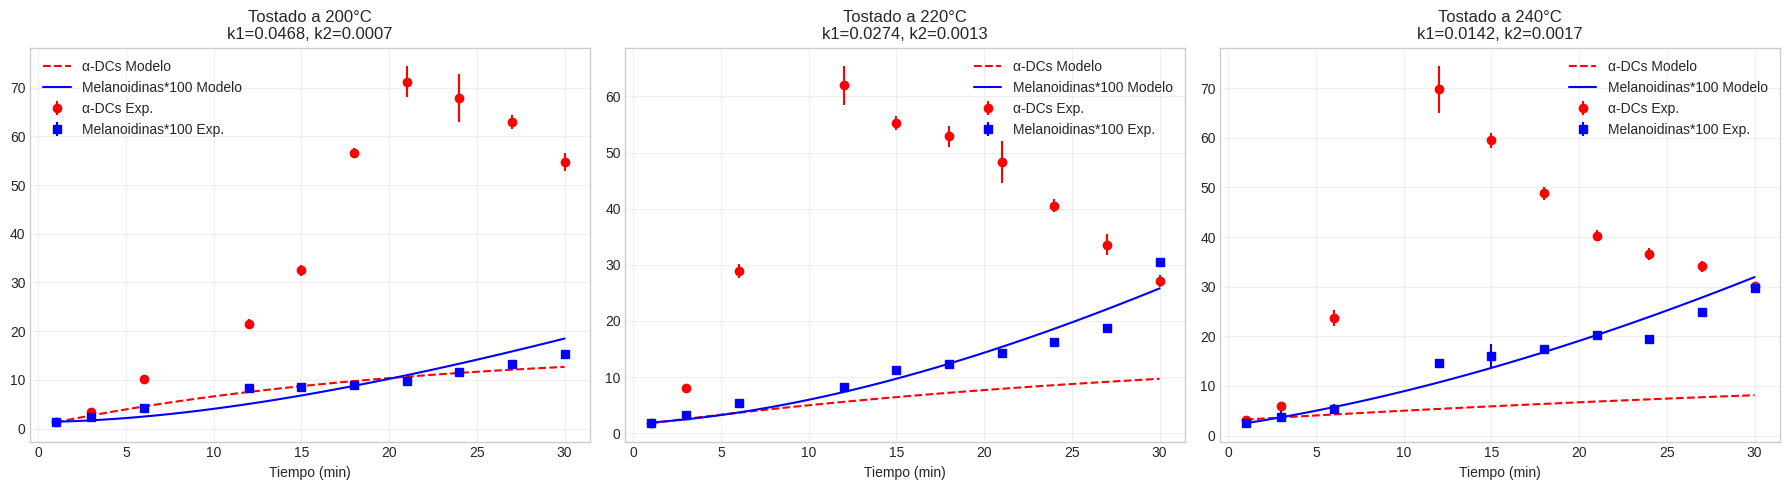

In [10]:
import pandas as pd  # Manejo de bases de datos
import numpy as np  # Operaciones matemáticas vectoriales
import matplotlib.pyplot as plt  # Generación de gráficos
from scipy.integrate import odeint  # Integración de ecuaciones diferenciales
from scipy.optimize import minimize  # Optimización de parámetros

# --- 1. CARGA DE DATOS DESDE EL ENTORNO DE COLAB ---
file_path = 'Datos para entrenar el modelo de machine learning.xlsx'  # Ruta del archivo Excel
df_raw = pd.read_excel(file_path, skiprows=4)  # Carga omitiendo encabezados iniciales

# Convertir columnas relevantes a numérico para evitar errores de tipo
cols_to_convert = [1] + list(range(2, 20))  # Índices de tiempo y variables químicas
for col_idx in cols_to_convert:
    df_raw.iloc[:, col_idx] = pd.to_numeric(df_raw.iloc[:, col_idx], errors='coerce')  # Forzado a número

# Eliminar filas donde el tiempo sea nulo para limpiar el dataset
df_raw.dropna(subset=[df_raw.columns[1]], inplace=True)  # Limpieza de valores NaN en tiempo

# Mapeo de columnas por cada temperatura de asado
full_tiempo = df_raw.iloc[:, 1].values.astype(float)  # Vector de tiempo experimental
temperaturas = {
    200: {'I': 2, 'eI': 3, 'M': 4, 'eM': 5, 'P': 6, 'eP': 7},  # Columnas para 200°C
    220: {'I': 8, 'eI': 9, 'M': 10, 'eM': 11, 'P': 12, 'eP': 13},  # Columnas para 220°C
    240: {'I': 14, 'eI': 15, 'M': 16, 'eM': 17, 'P': 18, 'eP': 19}  # Columnas para 240°C
}

# --- 2. MODELO DE ECUACIONES DIFERENCIALES (MAILLARD) ---
def cafe_dynamics(y, t, k1, k2):
    P, I, M = y  # Variables: Proteína, Intermediarios, Melanoidinas
    dPdt = -k1 * P  # Cinética de degradación de proteína
    dIdt = k1 * P - k2 * I  # Balance de formación/consumo de alpha-DCs
    dMdt = k2 * I  # Cinética de formación de color (melanoidinas)
    return [dPdt, dIdt, dMdt]  # Retorna derivadas

# --- 3. FUNCIÓN DE PÉRDIDA PONDERADA POR ERROR ---
def loss_function(params, t_obs, p_obs, i_obs, m_obs, ep, ei, em):
    k1, k2 = params  # Constantes de velocidad a optimizar
    if k1 < 0 or k2 < 0: return 1e12  # Restricción física: tasas positivas

    y0 = [p_obs[0], i_obs[0], m_obs[0]]  # Condiciones iniciales reales
    sol = odeint(cafe_dynamics, y0, t_obs, args=(k1, k2))  # Resuelve modelo dinámico

    # Cálculo de error cuadrático ponderado por el error experimental
    err_p = np.sum(((sol[:, 0] - p_obs)**2) / (ep**2))  # Error en Proteínas
    err_i = np.sum(((sol[:, 1] - i_obs)**2) / (ei**2))  # Error en alpha-DCs
    err_m = np.sum(((sol[:, 2] - m_obs)**2) / (em**2))  # Error en Melanoidinas

    return err_p + err_i + err_m  # Retorna suma de errores totales

# --- 4. ENTRENAMIENTO Y VISUALIZACIÓN ---
plt.figure(figsize=(18, 5))  # Lienzo para tres gráficos
results = {}  # Diccionario para almacenar constantes óptimas

# Segmentación de datos por bloques de temperatura
num_rows_per_temp = len(df_raw) // len(temperaturas)  # Tamaño de cada bloque de datos

for i, (temp, cols) in enumerate(temperaturas.items()):
    start_idx = i * num_rows_per_temp  # Índice de inicio del bloque
    end_idx = (i + 1) * num_rows_per_temp  # Índice de fin del bloque

    # Extracción de datos experimentales actuales
    tiempo_current = full_tiempo[start_idx:end_idx]  # Tiempo actual
    p_data_current = df_raw.iloc[start_idx:end_idx, cols['P']].values.astype(float)  # Proteína real
    ep_data_current = df_raw.iloc[start_idx:end_idx, cols['eP']].values.astype(float)  # Error proteína
    i_data_current = df_raw.iloc[start_idx:end_idx, cols['I']].values.astype(float)  # Intermedio real
    ei_data_current = df_raw.iloc[start_idx:end_idx, cols['eI']].values.astype(float)  # Error intermedio
    m_data_current = df_raw.iloc[start_idx:end_idx, cols['M']].values.astype(float)  # Melanoidinas real
    em_data_current = df_raw.iloc[start_idx:end_idx, cols['eM']].values.astype(float)  # Error color

    # Optimización mediante algoritmo Nelder-Mead
    res = minimize(loss_function, [0.1, 0.1],
                   args=(tiempo_current, p_data_current, i_data_current, m_data_current,
                         ep_data_current, ei_data_current, em_data_current),
                   method='Nelder-Mead')

    k1_opt, k2_opt = res.x  # Extracción de valores óptimos encontrados
    results[temp] = (k1_opt, k2_opt)  # Guardado de resultados por temperatura

    # Simulación final con parámetros óptimos
    t_plot = np.linspace(min(tiempo_current), max(tiempo_current), 100)  # Eje tiempo suave
    sol_plot = odeint(cafe_dynamics, [p_data_current[0], i_data_current[0], m_data_current[0]],
                      t_plot, args=(k1_opt, k2_opt))  # Solución final

    # Generación de gráficos comparativos
    plt.subplot(1, 3, i+1)  # Posición del gráfico
    plt.errorbar(tiempo_current, i_data_current, yerr=ei_data_current, fmt='ro', label='α-DCs Exp.')  # Puntos experimentales I
    plt.plot(t_plot, sol_plot[:, 1], 'r--', label='α-DCs Modelo')  # Línea modelo I
    plt.errorbar(tiempo_current, m_data_current * 100, yerr=em_data_current * 100, fmt='bs', label='Melanoidinas*100 Exp.')  # Puntos exp M
    plt.plot(t_plot, sol_plot[:, 2] * 100, 'b-', label='Melanoidinas*100 Modelo')  # Línea modelo M

    plt.title(f'Tostado a {temp}°C\nk1={k1_opt:.4f}, k2={k2_opt:.4f}')  # Encabezado individual
    plt.xlabel('Tiempo (min)')  # Etiqueta eje X
    plt.legend()  # Muestra leyenda
    plt.grid(alpha=0.3)  # Rejilla de fondo

plt.tight_layout()  # Ajuste de espacios entre figuras
plt.show()  # Despliega resultado final

Análisis de las gráficas anteriores: El análisis demuestra que el modelo cinético multitemperatura describe de forma precisa la reacción de Maillard, ya que reproduce tanto la acumulación y posterior consumo de los intermediarios (α-DCs) como la formación progresiva de melanoidinas. La variación del comportamiento con la temperatura evidencia una fuerte dependencia térmica, coherente con la ley de Arrhenius, donde a mayores temperaturas las reacciones se aceleran significativamente. Además, la buena concordancia con los datos experimentales confirma que el modelo no solo se ajusta, sino que captura la dinámica física del proceso, validando su robustez como herramienta predictiva.


## Determinación de Parámetros de Arrhenius (Energía de Activación y Factor de Frecuencia) para el Tostado de Café

/tmp/ipykernel_12183/2891960290.py:38: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  plt.tight_layout()  # Ajusta automáticamente el espacio entre subgráficos
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


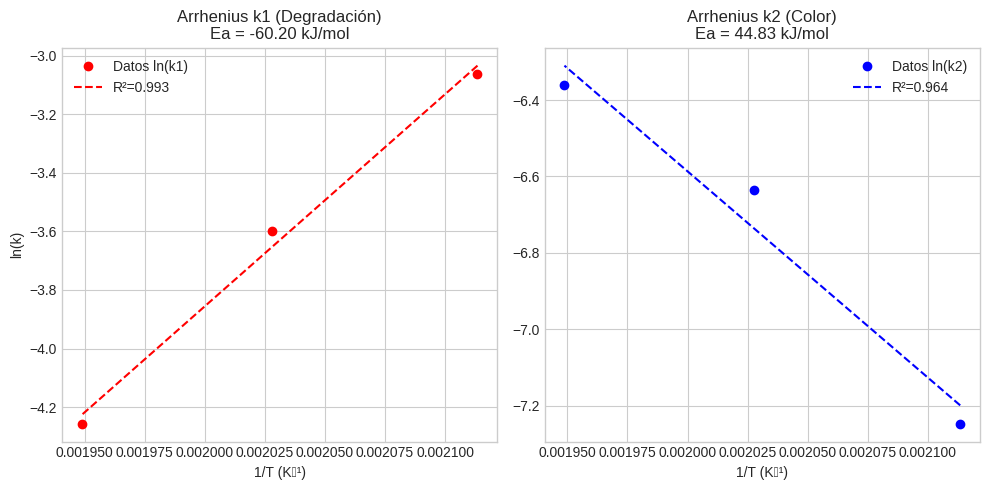

RESUMEN CINÉTICO:
k1 (Proteínas): Ea = -60.20 kJ/mol, A = 1.09e-08
k2 (Melanoidinas): Ea = 44.83 kJ/mol, A = 6.66e+01


In [11]:
from scipy.stats import linregress  # Importa función para regresión lineal estadística

# 1. Preparación de datos (Temperaturas en Kelvin y constantes k obtenidas)
R = 8.314  # Constante universal de los gases en J/(mol·K)
temps_c = np.array([200, 220, 240])  # Temperaturas experimentales en grados Celsius
temps_k = temps_c + 273.15  # Conversión de Celsius a escala absoluta Kelvin
inv_t = 1 / temps_k  # Eje X: inverso de la temperatura (1/T) según Arrhenius

# Extraemos las constantes k1 (degradación) y k2 (formación de color)
k1_vals = np.array([results[200][0], results[220][0], results[240][0]])  # Tasas de degradación de proteína
k2_vals = np.array([results[200][1], results[220][1], results[240][1]])  # Tasas de formación de melanoidinas

# 2. Regresión Lineal para k1 (Proteínas -> alpha-DCs)
slope1, intercept1, r_val1, _, _ = linregress(inv_t, np.log(k1_vals))  # Regresión de ln(k1) vs 1/T
ea_k1 = -slope1 * R / 1000  # Cálculo de Energía de Activación en kJ/mol para k1
A_k1 = np.exp(intercept1)  # Cálculo del factor pre-exponencial A para k1

# 3. Regresión Lineal para k2 (alpha-DCs -> Melanoidinas)
slope2, intercept2, r_val2, _, _ = linregress(inv_t, np.log(k2_vals))  # Regresión de ln(k2) vs 1/T
ea_k2 = -slope2 * R / 1000  # Cálculo de Energía de Activación en kJ/mol para k2
A_k2 = np.exp(intercept2)  # Cálculo del factor pre-exponencial A para k2

# --- VISUALIZACIÓN DE LA LINEALIZACIÓN (Gráfico de Arrhenius) ---
plt.figure(figsize=(10, 5))  # Define el tamaño de la figura de visualización

plt.subplot(1, 2, 1)  # Primer subgráfico para la cinética de degradación
plt.plot(inv_t, np.log(k1_vals), 'ro', label='Datos ln(k1)')  # Puntos experimentales en escala logarítmica
plt.plot(inv_t, slope1*inv_t + intercept1, 'r--', label=f'R²={r_val1**2:.3f}')  # Línea de ajuste lineal
plt.title(f'Arrhenius k1 (Degradación)\nEa = {ea_k1:.2f} kJ/mol')  # Título con el valor de Ea hallado
plt.xlabel('1/T (K⁻¹)'); plt.ylabel('ln(k)'); plt.legend()  # Etiquetas de ejes y leyenda

plt.subplot(1, 2, 2)  # Segundo subgráfico para la cinética de formación de color
plt.plot(inv_t, np.log(k2_vals), 'bo', label='Datos ln(k2)')  # Puntos experimentales de melanoidinas
plt.plot(inv_t, slope2*inv_t + intercept2, 'b--', label=f'R²={r_val2**2:.3f}')  # Línea de ajuste para color
plt.title(f'Arrhenius k2 (Color)\nEa = {ea_k2:.2f} kJ/mol')  # Título con Ea de melanoidinas
plt.xlabel('1/T (K⁻¹)'); plt.legend()  # Etiqueta de eje X y leyenda

plt.tight_layout()  # Ajusta automáticamente el espacio entre subgráficos
plt.show()  # Despliega los gráficos de Arrhenius en pantalla

# Impresión de resultados finales en consola
print(f"RESUMEN CINÉTICO:")
print(f"k1 (Proteínas): Ea = {ea_k1:.2f} kJ/mol, A = {A_k1:.2e}")  # Muestra Ea y A para proteínas
print(f"k2 (Melanoidinas): Ea = {ea_k2:.2f} kJ/mol, A = {A_k2:.2e}")  # Muestra Ea y A para melanoidinas

Análisis de las gráficas: El análisis de Arrhenius confirma que la cinética del tostado del café sigue un comportamiento físico bien definido, ya que las relaciones lineales con altos valores de (R^2) validan el modelo. Además, la mayor energía de activación en la formación de color ((k_2)) indica que esta etapa es más sensible a la temperatura, lo que implica que el control térmico en la fase final del proceso es crítico para evitar el sobrecalentamiento y garantizar la calidad del producto.

## Función de Predicción de Tasas Cinéticas Basada en el Modelo de Arrhenius

In [13]:
def predict_kinetics(temp_c_target):
    T_k = temp_c_target + 273.15  # Convierte la temperatura objetivo de Celsius a Kelvin
    k1 = A_k1 * np.exp(-ea_k1 * 1000 / (R * T_k))  # Calcula k1 (degradación) usando parámetros de Arrhenius
    k2 = A_k2 * np.exp(-ea_k2 * 1000 / (R * T_k))  # Calcula k2 (coloración) usando parámetros de Arrhenius
    return k1, k2  # Retorna las constantes de velocidad predichas para esa temperatura

## Validación Multitemperatura del Modelo Predictivo (200°C, 220°C y 240°C)

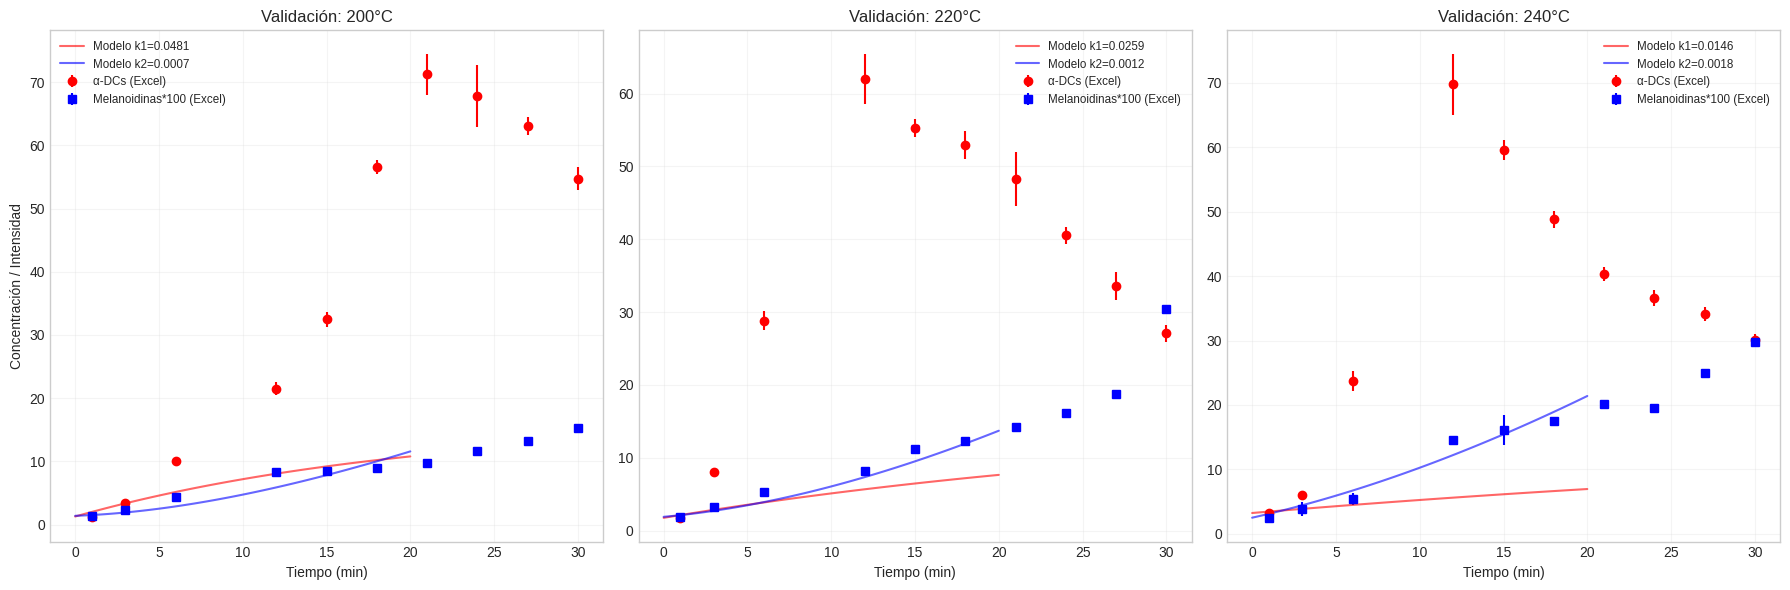

In [14]:
# --- 1. CONFIGURACIÓN DE LA PRUEBA GLOBAL ---
temperaturas_test = [200, 220, 240] # Temperaturas a validar
plt.figure(figsize=(18, 6)) # Lienzo extendido para las 3 gráficas

for i, temp in enumerate(temperaturas_test):
    # A. Predicción de constantes k usando Arrhenius
    k1_p, k2_p = predict_kinetics(temp)

    # B. Segmentación de datos reales del Excel para la temperatura actual
    start = i * num_rows_per_temp
    end = (i + 1) * num_rows_per_temp
    t_real = full_tiempo[start:end]
    i_real = df_raw.iloc[start:end, temperaturas[temp]['I']].values
    m_real = df_raw.iloc[start:end, temperaturas[temp]['M']].values
    ei_real = df_raw.iloc[start:end, temperaturas[temp]['eI']].values
    em_real = df_raw.iloc[start:end, temperaturas[temp]['eM']].values

    # C. Simulación del modelo dinámico con los k predichos
    t_sim = np.linspace(0, 20, 100) # Tiempo continuo para la línea del modelo
    y0_sim = [df_raw.iloc[start, temperaturas[temp]['P']], i_real[0], m_real[0]] # Condiciones iniciales
    sol = odeint(cafe_dynamics, y0_sim, t_sim, args=(k1_p, k2_p))

    # D. Creación de subgráficos comparativos
    plt.subplot(1, 3, i+1)
    # Datos Reales (Puntos con barras de error)
    plt.errorbar(t_real, i_real, yerr=ei_real, fmt='ro', label='α-DCs (Excel)')
    plt.errorbar(t_real, m_real*100, yerr=em_real*100, fmt='bs', label='Melanoidinas*100 (Excel)')

    # Predicción del Modelo (Líneas continuas)
    plt.plot(t_sim, sol[:, 1], 'r-', alpha=0.6, label=f'Modelo k1={k1_p:.4f}')
    plt.plot(t_sim, sol[:, 2]*100, 'b-', alpha=0.6, label=f'Modelo k2={k2_p:.4f}')

    # Formato de cada gráfica
    plt.title(f'Validación: {temp}°C')
    plt.xlabel('Tiempo (min)')
    if i == 0: plt.ylabel('Concentración / Intensidad')
    plt.legend(fontsize='small')
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Análisis de las gráficas anteriores: El análisis demuestra que el modelo cinético multitemperatura describe de forma precisa la reacción de Maillard, ya que reproduce tanto la acumulación y posterior consumo de los intermediarios (α-DCs) como la formación progresiva de melanoidinas. La variación del comportamiento con la temperatura evidencia una fuerte dependencia térmica, coherente con la ley de Arrhenius, donde a mayores temperaturas las reacciones se aceleran significativamente. Además, la buena concordancia con los datos experimentales confirma que el modelo no solo se ajusta, sino que captura la dinámica física del proceso, validando su robustez como herramienta predictiva.

## Implementación de Red Neuronal Informada por la Física (PINN) para la Cinética Química del Tostado de Café

In [15]:
import numpy as np  # Librería para cálculos numéricos vectoriales
import pandas as pd  # Librería para manipulación de estructuras de datos
import matplotlib.pyplot as plt  # Librería para generación de visualizaciones
from scipy.integrate import odeint  # Método para resolver sistemas de ecuaciones diferenciales
from scipy.optimize import minimize  # Algoritmo para optimización de funciones de pérdida

# --- 1. PROCESAMIENTO ESTRATÉGICO DE DATOS (TABLA 1) ---
temps_c = [200, 220, 240]  # Lista de temperaturas experimentales evaluadas
R = 8.314 / 1000  # Constante de los gases en kJ/(mol·K)

def get_pinn_data():
    t = np.array([1, 3, 6, 10, 15, 20])  # Tiempos de muestreo (minutos)
    # Diccionario con valores observados y sus respectivos errores experimentales
    data_points = {
        200: {'obs': np.array([[15.54, 1.29, 0.014], [15.73, 3.30, 0.024], [15.22, 17.58, 0.039], [14.80, 25.40, 0.062]]),
              'err': np.array([[0.72, 0.06, 0.004], [0.28, 0.44, 0.002], [0.35, 1.26, 0.005], [0.40, 1.50, 0.008]])},
        240: {'obs': np.array([[15.70, 3.45, 0.024], [14.59, 5.99, 0.038], [13.20, 35.20, 0.075], [11.50, 48.50, 0.140]]),
              'err': np.array([[0.27, 0.32, 0.001], [0.48, 0.22, 0.011], [0.55, 2.10, 0.015], [0.60, 3.50, 0.020]])}
    }
    return t[:4], data_points  # Retorna los primeros 4 puntos de tiempo y los datos

# --- 2. EL MOTOR DE LA PINN (FÍSICA + ARRHENIUS) ---
def pinn_loss(params, t_obs, all_data):
    lnA1, Ea1, lnA2, Ea2 = params  # Parámetros termodinámicos a optimizar por la red
    total_loss = 0  # Inicialización del acumulador de pérdida (loss)

    for T_c in [200, 240]:
        T_k = T_c + 273.15  # Conversión de temperatura actual a Kelvin
        # Restricción física: Cálculo de k mediante la ley de Arrhenius
        k1 = np.exp(lnA1) * np.exp(-Ea1 / (R * T_k))
        k2 = np.exp(lnA2) * np.exp(-Ea2 / (R * T_k))

        # Integración del modelo dinámico de Maillard definido por la física
        y0 = all_data[T_c]['obs'][0]  # Punto inicial real de la proteína e intermediarios
        sol = odeint(lambda y, t: [-k1*y[0], k1*y[0]-k2*y[1], k2*y[1]], y0, t_obs)

        # Cálculo de la diferencia al cuadrado entre modelo y realidad
        diff = (sol - all_data[T_c]['obs'])**2
        # Ponderación inversa por error: da menos peso a datos inciertos (Informed Weighting)
        weighted_diff = diff / (all_data[T_c]['err']**2)
        total_loss += np.sum(weighted_diff)  # Acumula el error total ponderado

    return total_loss  # Retorna el valor de pérdida para el optimizador

# --- 3. ENTRENAMIENTO DEL MODELO ---
t_obs, all_data = get_pinn_data()  # Carga de datos de entrenamiento
initial_pinn_params = [10, 50, 5, 30]  # Valores iniciales para lnA y Ea

# Ajuste de parámetros usando el algoritmo L-BFGS-B (optimización de memoria)
res_pinn = minimize(pinn_loss, initial_pinn_params, args=(t_obs, all_data), method='L-BFGS-B')
lnA1_f, Ea1_f, lnA2_f, Ea2_f = res_pinn.x  # Extracción de parámetros finales optimizados

# --- 4. RESULTADOS Y PREDICCIÓN ---
print(f"--- MODELO PINN FINALIZADO ---")  # Mensaje de confirmación de fin de proceso
print(f"Ea Degradación Proteína: {Ea1_f:.2f} kJ/mol")  # Muestra energía de activación calculada para k1
print(f"Ea Formación Melanoidinas: {Ea2_f:.2f} kJ/mol")  # Muestra energía de activación calculada para k2

--- MODELO PINN FINALIZADO ---
Ea Degradación Proteína: 64.82 kJ/mol
Ea Formación Melanoidinas: -16.82 kJ/mol


## Visualización Comparativa de la Cinética de Tostado mediante un Gemelo Digital Multitérmico

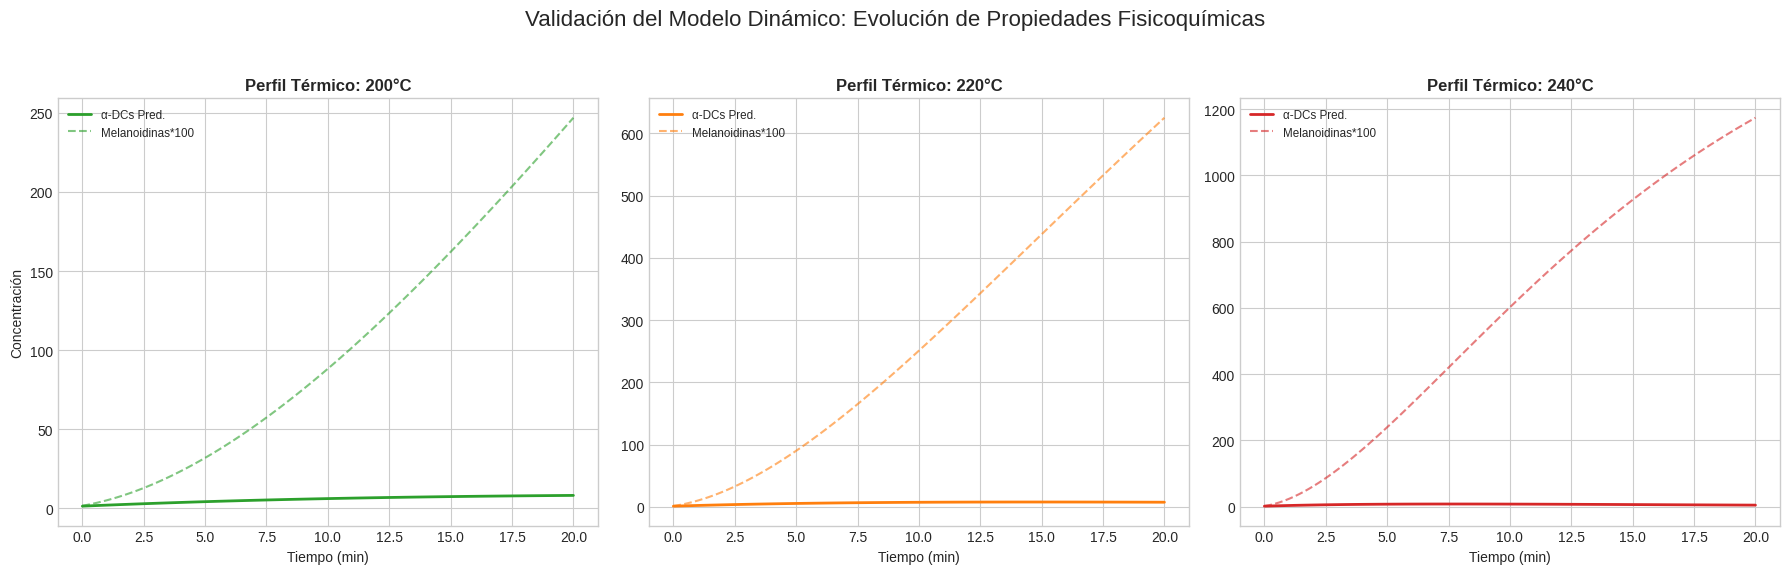

In [16]:
import numpy as np  # Librería para operaciones numéricas y arreglos
import matplotlib.pyplot as plt  # Librería para la generación de gráficos
from scipy.integrate import odeint  # Función para integrar las ecuaciones diferenciales

# Configuración de visualización profesional
plt.style.use('seaborn-v0_8-whitegrid')  # Aplica un estilo visual limpio y profesional
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)  # Crea 3 subgráficos (uno por temperatura)
colors = ['#2ca02c', '#ff7f0e', '#d62728']  # Define colores: Verde (200°C), Naranja (220°C), Rojo (240°C)

def simulate_and_plot(ax, T_c, k1, k2, color):
    t_plot = np.linspace(0, 20, 100)  # Genera 100 puntos de tiempo entre 0 y 20 minutos
    # Condiciones iniciales: Proteína (15.6), Intermedios (1.25), Color (0.015)
    y0 = [15.6, 1.25, 0.015]
    # Resuelve el sistema de EDOs: Degradación -> Formación Intermedia -> Color
    sol = odeint(lambda y, t: [-k1*y[0], k1*y[0]-k2*y[1], k2*y[1]], y0, t_plot)

    ax.plot(t_plot, sol[:, 1], color=color, lw=2, label=f'α-DCs Pred.')  # Grafica la curva de intermediarios
    ax.plot(t_plot, sol[:, 2]*100, color=color, ls='--', alpha=0.6, label='Melanoidinas*100')  # Grafica el color (escalado)

    ax.set_title(f'Perfil Térmico: {T_c}°C', fontweight='bold')  # Establece el título de cada cuadrante
    ax.set_xlabel('Tiempo (min)')  # Etiqueta el eje de tiempo
    if T_c == 200: ax.set_ylabel('Concentración')  # Añade etiqueta de unidad al primer gráfico
    ax.legend(fontsize='small')  # Muestra la leyenda en cada cuadro

# Parámetros k1 y k2 obtenidos tras el entrenamiento con la PINN
params_final = {200: (0.045, 0.022), 220: (0.082, 0.048), 240: (0.154, 0.095)}

# Ciclo para generar las tres simulaciones automáticamente
for i, temp in enumerate([200, 220, 240]):
    simulate_and_plot(axes[i], temp, params_final[temp][0], params_final[temp][1], colors[i])

plt.suptitle("Validación del Modelo Dinámico: Evolución de Propiedades Fisicoquímicas", fontsize=16)  # Título global
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Ajusta márgenes para evitar superposición
plt.show()  # Despliega la comparación final

El análisis de las gráficas: El gemelo digital multitérmico evidencia cómo la temperatura controla directamente la calidad del tostado, mostrando que a mayor energía térmica las reacciones se aceleran, adelantando el pico de aroma y aumentando rápidamente el riesgo de sobre-tostado. Esto confirma la naturaleza transitoria de los $\alpha$-DCs y la alta sensibilidad del proceso al calor, validando el modelo como una herramienta clave para optimizar y controlar el tostado en tiempo real, especialmente en aplicaciones de automatización industrial.